In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
# Check for missing values in each column
print("Missing values per column:")
print(X.isnull().sum())
# Look at the first 5 rows to understand the 'features'
X.head()

Missing values per column:
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


/tmp/ipykernel_318/3862840186.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.values.ravel(), palette='RdYlGn')


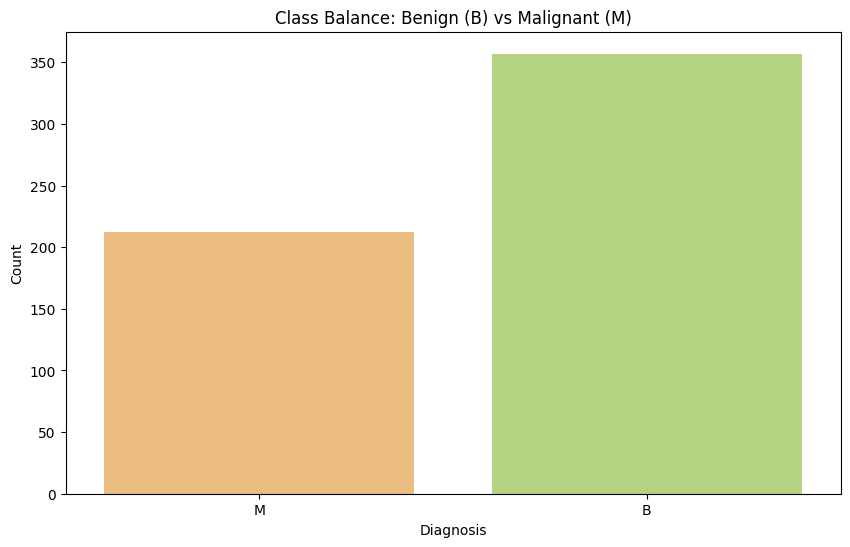

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
# Pass the 1D NumPy array 'y' directly to countplot
sns.countplot(x=y.values.ravel(), palette='RdYlGn')
plt.title('Class Balance: Benign (B) vs Malignant (M)') # Updated title for generic classes
plt.xlabel('Diagnosis') # Updated label for generic classes
plt.ylabel('Count')
plt.show()

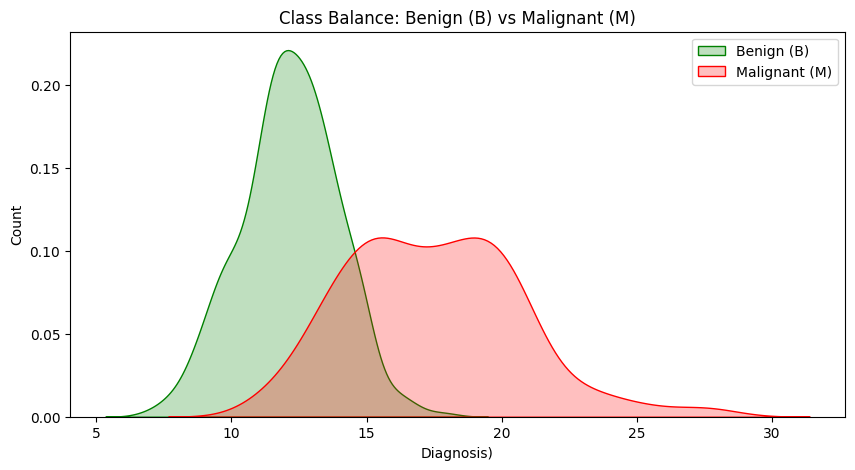

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y = y.squeeze() # Convert the single-column DataFrame to a Series

plt.figure(figsize=(10,5))

X_df = pd.DataFrame(X)

sns.kdeplot(X_df[y == 'B']['radius1'], label="Benign (B)", fill=True, color='green')
sns.kdeplot(X_df[y == 'M']['radius1'], label="Malignant (M)", fill=True, color='red')

plt.title('Class Balance: Benign (B) vs Malignant (M)')
plt.xlabel('Diagnosis)')
plt.ylabel('Count')
plt.legend()
plt.show()

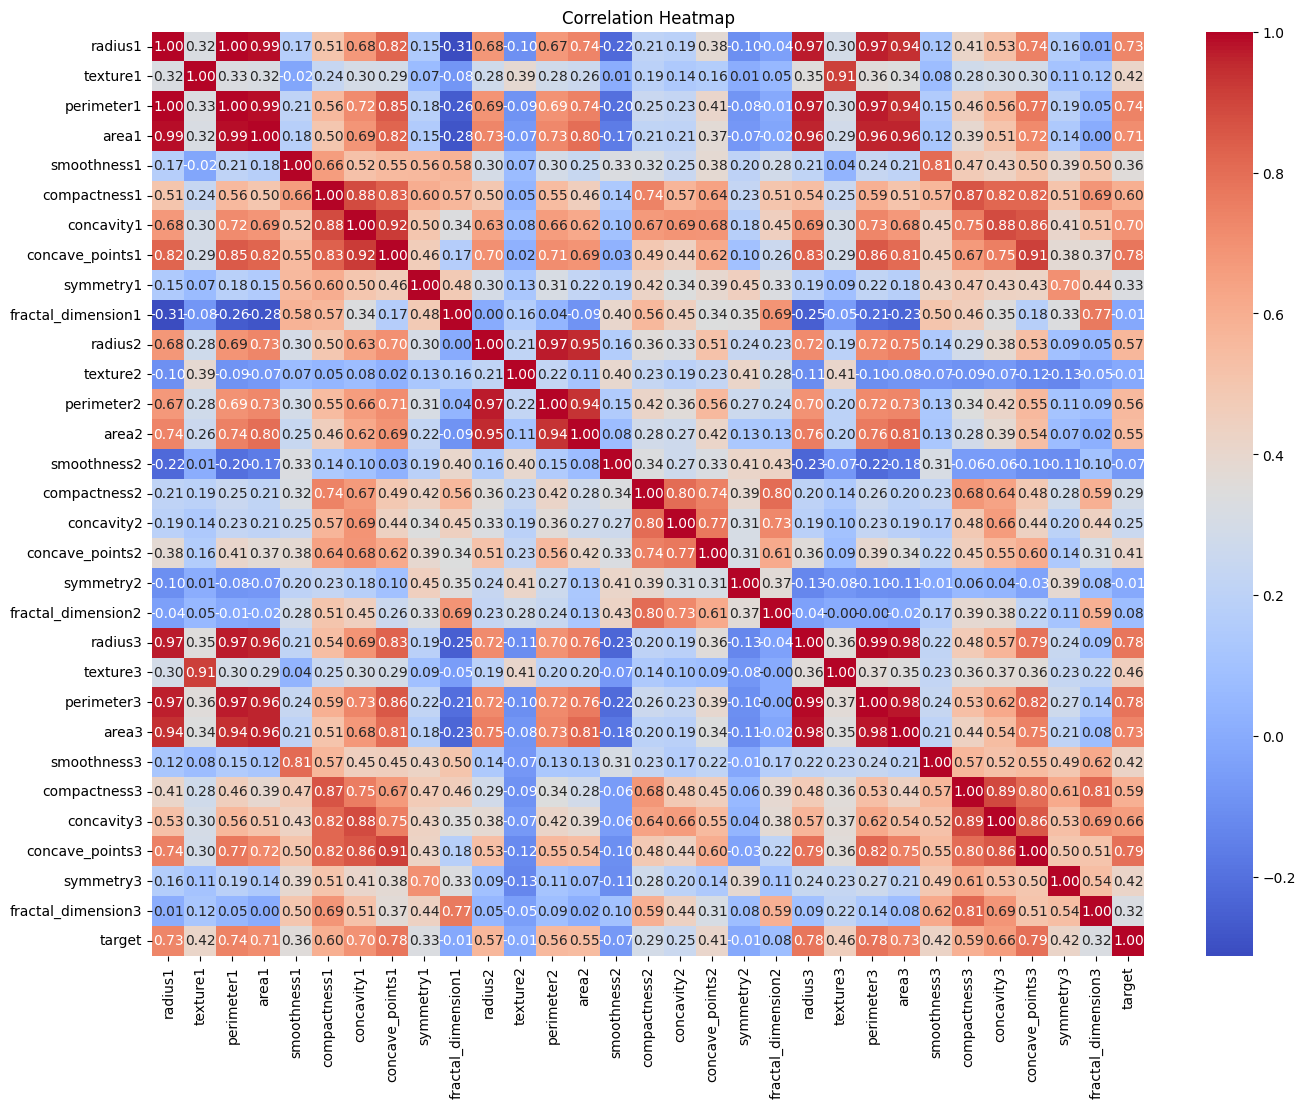

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap
temp_df = pd.DataFrame(X.copy()) # Convert X to a DataFrame
# Convert 'y' to numerical representation for correlation calculation
temp_df['target'] = pd.Series(y).map({'M': 1, 'B': 0}) # Map 'M' to 1 and 'B' to 0
plt.figure(figsize=(16,12))
sns.heatmap(temp_df.corr(),annot = True, cmap ='coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_clean = pd.DataFrame(X).fillna(pd.DataFrame(X).mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y, # y is now a numpy array, pass it directly
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Initialize the Random Forest classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# calculate Training Accuracy
train_accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred)}")

Training Accuracy: 1.0
Testing Accuracy: 0.9649122807017544


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# 1. Initialize the model with optimized parameters
final_rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    max_features='sqrt',
    max_samples=0.8,
    min_samples_leaf=1,
    min_samples_split=5,
    bootstrap=True,
    random_state=42
)
# 2. Train the model
final_rf_model.fit(X_train, y_train)
# 3. Evaluate and show results to students
y_pred = final_rf_model.predict(X_test)
print("--- Final Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

--- Final Random Forest Performance ---
Accuracy Score: 0.9649

Detailed Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_convergence_rf = RandomForestClassifier(
    n_estimators=120,      # More trees for stability
    max_depth=7,           # Slightly shallow trees
    min_samples_leaf=10,   # Prevent overfitting
    min_samples_split=20,  # Require more samples before splitting
    max_features='sqrt',   # Standard RF practice
    bootstrap=True,
    random_state=42
)

final_convergence_rf.fit(X_train, y_train)

# Calculate scores
train_score = final_convergence_rf.score(X_train, y_train)
test_score = final_convergence_rf.score(X_test, y_test)

print(f"Final RF Training Accuracy: {train_score:.4f}")
print(f"Final RF Test Accuracy: {test_score:.4f}")
print(f"Final RF Gap: {train_score - test_score:.4f}")

Final RF Training Accuracy: 0.9670
Final RF Test Accuracy: 0.9649
Final RF Gap: 0.0021


In [ ]:
sample = X_test.iloc[0:1]

prediction = final_convergence_rf.predict(sample)
probability = final_convergence_rf.predict_proba(sample)

print("Clinical Diagnosis Result")

if prediction[0] == 'M':
    print("Diagnosis: Malignant Tumor (Breast Cancer Detected)")
else:
    print("Diagnosis: Benign Tumor (Non-Cancerous)")

print(f"Prediction Confidence: {max(probability[0])*100:.2f}%")

Clinical Diagnosis Result
Diagnosis: Benign Tumor (Non-Cancerous)
Prediction Confidence: 95.98%


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# Boosting: Learning from mistakes sequentially
boosted_model = GradientBoostingClassifier(
    n_estimators=50,      # Same number of trees as your RF
    learning_rate=0.1,     # NEW: The "step size" (crucial for Boosting)
    max_depth=3,           # REDUCED: Boosting works best with very shallow trees
    min_samples_leaf=5,    # Consistent with your RF
    min_samples_split=10,  # Consistent with your RF
    subsample=0.7,         # Equivalent to your 'max_samples'
    max_features='sqrt',   # Consistent with your RF
    random_state=42
)
boosted_model.fit(X_train, y_train)
# Check the Boosting scores
boost_train_score = boosted_model.score(X_train, y_train)
boost_test_score = boosted_model.score(X_test, y_test)
print(f"Boosting Training Accuracy: {boost_train_score:.4f}")
print(f"Boosting Test Accuracy: {boost_test_score:.4f}")
print(f"Boosting Gap: {boost_train_score - boost_test_score:.4f}")

Boosting Training Accuracy: 0.9956
Boosting Test Accuracy: 0.9649
Boosting Gap: 0.0307


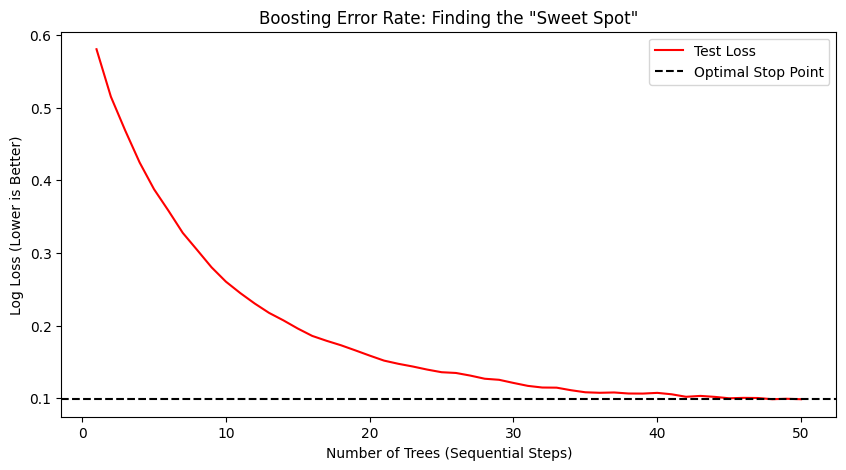

In [ ]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np
# 1. Initialize an array to store the loss at each of the 300 steps
test_losses = []
# 2. staged_predict_proba gives us the "certainty" of the model at each tree
for y_proba in boosted_model.staged_predict_proba(X_test):
    test_losses.append(log_loss(y_test, y_proba))
# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(test_losses) + 1), test_losses, color='red', label='Test Loss')
plt.axhline(y=min(test_losses), color='black', linestyle='--', label='Optimal Stop Point')
plt.title('Boosting Error Rate: Finding the "Sweet Spot"')
plt.xlabel('Number of Trees (Sequential Steps)')
plt.ylabel('Log Loss (Lower is Better)')
plt.legend()
plt.show()